In [30]:
# Прогноз: перші h годин календарного дня (h = 1 … n−1, n = кількість барів у дні)
# → CLOSE останнього бару цього дня. X: (N, T_max, F), паддинг 0 під Keras Masking.

import os

os.environ.setdefault("KERAS_BACKEND", "torch")
from keras.utils import set_random_seed

set_random_seed(42)

from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

CSV_PATH = Path("bitcoin-hourly-technical-indicators.csv")
MAX_PREFIX_HOURS = 23  # None = без обмеження; інакше h не більше цього значення
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

def load_and_clean(path: Path) -> tuple[pd.DataFrame, list[str]]:
    df = pd.read_csv(path)
    df["dt"] = pd.to_datetime(df["DATETIME"])
    df = df.sort_values("dt").reset_index(drop=True)
    df["day"] = df["dt"].dt.normalize()

    meta = {"UNIX_TIMESTAMP", "DATETIME", "dt", "day"}
    feature_cols = [
        c
        for c in df.columns
        if c not in meta and pd.api.types.is_numeric_dtype(df[c])
    ]
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    df[feature_cols] = df[feature_cols].ffill().fillna(0.0)
    return df, feature_cols

def build_sequences(
    df: pd.DataFrame,
    feature_cols: list[str],
    max_prefix_hours: int | None = MAX_PREFIX_HOURS,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int, int]:
    seqs: list[np.ndarray] = []
    targets: list[float] = []
    lengths: list[int] = []
    day_ids: list[pd.Timestamp] = []

    for _day, g in df.groupby("day", sort=False):
        g = g.sort_values("dt")
        n = len(g)
        if n < 2:
            continue
        day_close = float(g["CLOSE"].iloc[-1])
        mat = g[feature_cols].to_numpy(dtype=np.float32)
        h_max = n - 1
        if max_prefix_hours is not None:
            h_max = min(h_max, max_prefix_hours)
        for h in range(1, h_max + 1):
            seqs.append(mat[:h].copy())
            targets.append(day_close)
            lengths.append(h)
            day_ids.append(pd.Timestamp(_day))

    if not seqs:
        raise ValueError("Не вдалося зібрати жодного зразка (перевір CSV і колонки).")

    T_max = max(lengths)
    F = seqs[0].shape[1]
    X = np.zeros((len(seqs), T_max, F), dtype=np.float32)
    for i, block in enumerate(seqs):
        h = block.shape[0]
        X[i, :h, :] = block

    y = np.asarray(targets, dtype=np.float64)
    lengths_arr = np.asarray(lengths, dtype=np.int32)
    day_ids_arr = np.asarray(day_ids)
    return X, y, lengths_arr, day_ids_arr, T_max, F

def split_day_sets(day_ids: np.ndarray, train_f: float, val_f: float):
    u = np.array(sorted(np.unique(day_ids)))
    n = len(u)
    n_tr = int(n * train_f)
    n_va = int(n * val_f)
    train_days = set(u[:n_tr].tolist())
    val_days = set(u[n_tr : n_tr + n_va].tolist())
    test_days = set(u[n_tr + n_va :].tolist())
    return train_days, val_days, test_days

def mask_by_days(day_ids: np.ndarray, days: set) -> np.ndarray:
    return np.array([d in days for d in day_ids], dtype=bool)

df_raw, FEATURE_COLS = load_and_clean(CSV_PATH)
X_all, y_all, lengths_all, day_all, T_MAX, N_FEAT = build_sequences(
    df_raw, FEATURE_COLS, max_prefix_hours=MAX_PREFIX_HOURS
)

train_days, val_days, test_days = split_day_sets(day_all, TRAIN_FRAC, VAL_FRAC)
m_tr = mask_by_days(day_all, train_days)
m_va = mask_by_days(day_all, val_days)
m_te = mask_by_days(day_all, test_days)

X_train, y_train, lengths_train = X_all[m_tr], y_all[m_tr], lengths_all[m_tr]
X_val, y_val, lengths_val = X_all[m_va], y_all[m_va], lengths_all[m_va]
X_test, y_test, lengths_test = X_all[m_te], y_all[m_te], lengths_all[m_te]

feature_scaler = StandardScaler()
feature_scaler.fit(X_train.reshape(-1, N_FEAT))


def scale_X(X: np.ndarray, lengths: np.ndarray) -> np.ndarray:
    n, t, f = X.shape
    out = feature_scaler.transform(X.reshape(-1, f)).astype(np.float32).reshape(n, t, f)
    for i in range(n):
        h = int(lengths[i])
        out[i, h:, :] = 0.0
    return out


X_train = scale_X(X_train, lengths_train)
X_val = scale_X(X_val, lengths_val)
X_test = scale_X(X_test, lengths_test)

y_test_original = y_test.astype(np.float64).copy()
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).astype(np.float32).ravel()
y_val = y_scaler.transform(y_val.reshape(-1, 1)).astype(np.float32).ravel()
y_test = y_scaler.transform(y_test.reshape(-1, 1)).astype(np.float32).ravel()

print("CSV:", CSV_PATH)
print("X_train:", X_train.shape, "y_train:", y_train.shape, "lengths_train:", lengths_train.shape)
print("X_val:  ", X_val.shape, "X_test:", X_test.shape)
print("T_MAX =", T_MAX, "N_FEAT =", N_FEAT)
print("Дні: train", len(train_days), "val", len(val_days), "test", len(test_days))

CSV: bitcoin-hourly-technical-indicators.csv
X_train: (92552, 23, 84) y_train: (92552,) lengths_train: (92552,)
X_val:   (19826, 23, 84) X_test: (19872, 23, 84)
T_MAX = 23 N_FEAT = 84
Дні: train 4024 val 862 test 864


In [51]:
import os

os.environ["KERAS_BACKEND"] = "torch"

from keras import regularizers
from keras.layers import Dense, Flatten, Input
from keras.models import Sequential
from keras.optimizers import Adam

_l2 = regularizers.l2(1e-4)

model = Sequential(
    [
        Input(shape=(T_MAX, N_FEAT)),
        Flatten(),
        Dense(256, activation="relu", kernel_regularizer=_l2),
        Dense(128, activation="relu", kernel_regularizer=_l2),
        Dense(64, activation="relu", kernel_regularizer=_l2),
        Dense(1),
    ]
)
model.compile(optimizer=Adam(learning_rate=0.0001), loss="mse")
model.summary()


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_19 (Flatten)            │ (None, 1932)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 256)            │       494,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,065 (2.04 MB)

 Trainable params: 536,065 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os

import numpy as np

os.environ.setdefault("KERAS_BACKEND", "torch")
from keras.callbacks import EarlyStopping

EPOCHS = 40
BATCH = 512

early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[early],
    verbose=1,
)

test_mse = model.evaluate(X_test, y_test, batch_size=BATCH, verbose=0)
print("Test MSE (loss, scaled y):", test_mse)

y_hat = model.predict(X_test, batch_size=BATCH, verbose=0).ravel()
y_hat_orig = y_scaler.inverse_transform(y_hat.reshape(-1, 1)).ravel()
print(
    "Test MAE (оригінальна ціна):",
    float(np.mean(np.abs(y_hat_orig - y_test_original))),
)


Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0052 - val_loss: 0.0137
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0050 - val_loss: 0.0146
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0048 - val_loss: 0.0150
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0047 - val_loss: 0.0131
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0046 - val_loss: 0.0126
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0044 - val_loss: 0.0130
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0044 - val_loss: 0.0130
Epoch 8/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0042 - val_loss: 0.0123
Epoch 9/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0041 - val_loss: 0.0132
Epoch 10/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0040 - val_loss: 0.0123
Epoch 11/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0039 - val_loss: 0.0124
Test MSE (loss, scaled y): 0.042280010879

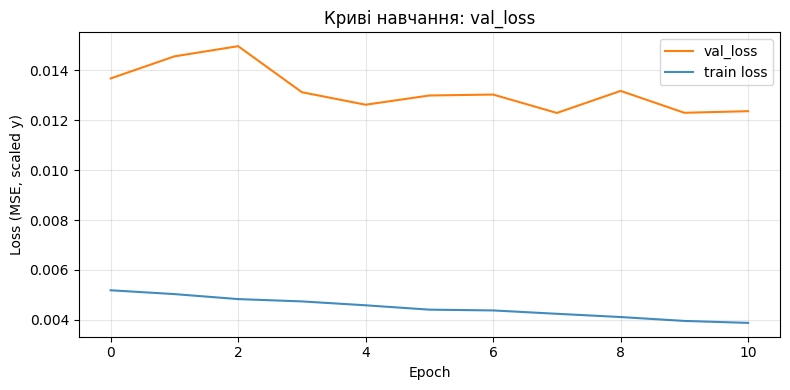

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["val_loss"], label="val_loss", color="tab:orange")
ax.plot(history.history["loss"], label="train loss", color="tab:blue", alpha=0.85)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE, scaled y)")
ax.set_title("Криві навчання: val_loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
